# VoxIntel — 13: Taxonomy Validation and Refinement

## Why this notebook comes next

Notebook 12 successfully consolidated VoxIntel into a clean research state.
That was necessary, but it did not fully solve the **quality** question of the taxonomy itself.

The main remaining concern is that one category — `proper_noun_error` — dominates the repaired taxonomy.
If a single category absorbs most errors, then the taxonomy may still be too coarse to support strong research claims.

So this notebook does **not** train any new model.
It does something more important scientifically:

> **validate whether the taxonomy is believable, and refine it where necessary**

---

## Core questions

This notebook asks five questions:

1. Is the repaired taxonomy internally consistent?
2. Is `proper_noun_error` overfiring?
3. Can we split `proper_noun_error` into more meaningful subtypes?
4. Are high-impact conclusions stable after refinement?
5. Is the taxonomy trustworthy enough to use in later research notebooks?

---

## Research principle

A taxonomy is only useful if it improves understanding.
If one giant bucket dominates the data, the taxonomy has low explanatory value.

So the goal here is not just to make labels look nicer. The goal is to increase:

- **interpretability**
- **category specificity**
- **downstream explanatory power**

That is what makes the analysis layer research-worthy.


## Cell 0 — Make sure `src` is importable


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: c:\Users\ACER\OneDrive\Desktop\VoxIntel


## Cell 1 — Imports


In [2]:
import json
import math
import random
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


## Cell 2 — Load canonical post-consolidation outputs


In [3]:
REPORTS_DIR = PROJECT_ROOT / "reports"
ERROR_TAXONOMY_PATH = REPORTS_DIR / "error_taxonomy_dataset.csv"
ERROR_IMPACT_MATRIX_PATH = REPORTS_DIR / "error_impact_matrix.csv"
ERROR_TYPE_DISTRIBUTION_PATH = REPORTS_DIR / "error_type_distribution.csv"
INTENT_FRAGILITY_PATH = REPORTS_DIR / "intent_fragility.csv"

for path in [ERROR_TAXONOMY_PATH, ERROR_IMPACT_MATRIX_PATH, ERROR_TYPE_DISTRIBUTION_PATH, INTENT_FRAGILITY_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required canonical report file: {path}")

taxonomy_df = pd.read_csv(ERROR_TAXONOMY_PATH)
error_impact_matrix_df = pd.read_csv(ERROR_IMPACT_MATRIX_PATH)
error_type_distribution_df = pd.read_csv(ERROR_TYPE_DISTRIBUTION_PATH)
intent_fragility_df = pd.read_csv(INTENT_FRAGILITY_PATH)

print(taxonomy_df.shape)
display(error_type_distribution_df)


(8688, 41)


,error_type,baseline,finetuned,delta_finetuned_minus_baseline
0,deletion,19,59,40
1,entity_error,43,46,3
2,no_error,565,1843,1278
3,number_error,488,253,-235
4,proper_noun_error,7573,6487,-1086


## Cell 3 — First sanity check: how dominant is `proper_noun_error`?

A category can be important without being problematic.
It becomes problematic when it dominates so much that it starts to behave like a catch-all bucket.

This cell quantifies that dominance directly.


In [4]:
dominance_summary_df = pd.DataFrame([
    {
        "system": "baseline",
        "proper_noun_fraction": (taxonomy_df["baseline_primary_error_type"] == "proper_noun_error").mean(),
        "no_error_fraction": (taxonomy_df["baseline_primary_error_type"] == "no_error").mean(),
        "n_unique_error_types": taxonomy_df["baseline_primary_error_type"].nunique(),
    },
    {
        "system": "finetuned",
        "proper_noun_fraction": (taxonomy_df["finetuned_primary_error_type"] == "proper_noun_error").mean(),
        "no_error_fraction": (taxonomy_df["finetuned_primary_error_type"] == "no_error").mean(),
        "n_unique_error_types": taxonomy_df["finetuned_primary_error_type"].nunique(),
    },
])

display(dominance_summary_df)


,system,proper_noun_fraction,no_error_fraction,n_unique_error_types
0,baseline,0.871662,0.065032,5
1,finetuned,0.746662,0.212132,5


## Cell 4 — Theory: why `proper_noun_error` may be inflated

In ASR outputs, all-uppercase transcripts are common.
If a rule treats capitalization itself as evidence of proper nouns, then ordinary words can be misclassified as name/entity errors.

That leads to a category that is partly:

- true named entities
- true media titles
- true person/location names
- but also generic capitalized tokens caused by ASR formatting

So we need to refine the category.


## Cell 5 — Build helper heuristics for subtype refinement


In [5]:
COMMON_ENTITY_HINTS = {
    "japanese", "american", "twitter", "facebook", "youtube", "spotify", "washington",
    "london", "paris", "tokyo", "monday", "tuesday", "wednesday", "thursday", "friday",
    "saturday", "sunday", "amy", "john", "raju", "yahoo", "google", "netflix"
}

GENERIC_QUERY_WORDS = {
    "what", "when", "where", "who", "how", "why", "play", "call", "set", "remove",
    "weather", "news", "music", "email", "list", "alarm", "calendar", "query"
}

WORD_RE = re.compile(r"[A-Za-z0-9']+")


def tokenize_words(text):
    return WORD_RE.findall(str(text))


def lowercase_tokens(text):
    return [t.lower() for t in tokenize_words(text)]


def classify_proper_noun_subtype(ground_truth_text, hypothesis_text, alignment_summary):
    gt_raw = tokenize_words(ground_truth_text)
    hyp_raw = tokenize_words(hypothesis_text)
    gt_lower = [t.lower() for t in gt_raw]
    hyp_lower = [t.lower() for t in hyp_raw]
    combined_lower = gt_lower + hyp_lower

    if any(tok in COMMON_ENTITY_HINTS for tok in combined_lower):
        return "entity_like"

    if any(tok.istitle() for tok in gt_raw + hyp_raw):
        return "capitalized_name_like"

    if any(tok.isupper() for tok in gt_raw + hyp_raw):
        return "uppercase_formatting_like"

    if any(tok in GENERIC_QUERY_WORDS for tok in combined_lower):
        return "generic_content_word"

    return "other"


## Cell 6 — Refine `proper_noun_error` into subtypes

This does not replace the original taxonomy yet.
It creates a validation layer on top of it, so we can see whether the bucket is meaningful or too broad.


In [6]:
refined_df = taxonomy_df.copy()

refined_df["baseline_proper_noun_subtype"] = refined_df.apply(
    lambda row: classify_proper_noun_subtype(
        row["ground_truth"],
        row["baseline_transcript"],
        row["baseline_alignment_summary"],
    ) if row["baseline_primary_error_type"] == "proper_noun_error" else "not_applicable",
    axis=1,
)

refined_df["finetuned_proper_noun_subtype"] = refined_df.apply(
    lambda row: classify_proper_noun_subtype(
        row["ground_truth"],
        row["finetuned_transcript"],
        row["finetuned_alignment_summary"],
    ) if row["finetuned_primary_error_type"] == "proper_noun_error" else "not_applicable",
    axis=1,
)

print("Refinement columns added.")


Refinement columns added.


## Cell 7 — Distribution of proper-noun subtypes


In [7]:
baseline_subtypes_df = refined_df.loc[
    refined_df["baseline_primary_error_type"] == "proper_noun_error",
    "baseline_proper_noun_subtype"
].value_counts().rename_axis("subtype").reset_index(name="baseline_samples")

finetuned_subtypes_df = refined_df.loc[
    refined_df["finetuned_primary_error_type"] == "proper_noun_error",
    "finetuned_proper_noun_subtype"
].value_counts().rename_axis("subtype").reset_index(name="finetuned_samples")

proper_noun_subtype_distribution_df = baseline_subtypes_df.merge(
    finetuned_subtypes_df, on="subtype", how="outer"
).fillna(0)

for col in ["baseline_samples", "finetuned_samples"]:
    proper_noun_subtype_distribution_df[col] = proper_noun_subtype_distribution_df[col].astype(int)

display(proper_noun_subtype_distribution_df)


,subtype,baseline_samples,finetuned_samples
0,capitalized_name_like,2121,1482
1,entity_like,522,498
2,uppercase_formatting_like,4930,4507


## Cell 8 — Manual validation sample design

For taxonomy validation, the right move is not to label all 8,688 rows manually.
Instead, we sample strategically.

We want examples from:
- `proper_noun_error`
- `number_error`
- `entity_error`
- `deletion`
- `no_error`

That gives us a compact audit set for human verification.


In [8]:
def stratified_sample(df, col, n_per_group=20, seed=SEED):
    parts = []
    for key, group in df.groupby(col):
        take = min(n_per_group, len(group))
        parts.append(group.sample(take, random_state=seed))
    return pd.concat(parts).reset_index(drop=True)

baseline_validation_sample_df = stratified_sample(
    refined_df[[
        "intent", "scenario", "ground_truth", "baseline_transcript",
        "baseline_primary_error_type", "baseline_proper_noun_subtype",
        "baseline_alignment_summary", "baseline_correct", "baseline_confidence"
    ]],
    col="baseline_primary_error_type",
    n_per_group=20,
)

finetuned_validation_sample_df = stratified_sample(
    refined_df[[
        "intent", "scenario", "ground_truth", "finetuned_transcript",
        "finetuned_primary_error_type", "finetuned_proper_noun_subtype",
        "finetuned_alignment_summary", "finetuned_correct", "finetuned_confidence"
    ]],
    col="finetuned_primary_error_type",
    n_per_group=20,
)

print("Baseline validation sample:", baseline_validation_sample_df.shape)
print("Fine-tuned validation sample:", finetuned_validation_sample_df.shape)


Baseline validation sample: (99, 9)
Fine-tuned validation sample: (100, 9)


## Cell 9 — Show baseline validation sample for manual review


In [9]:
display(baseline_validation_sample_df.head(40))


,intent,scenario,ground_truth,baseline_transcript,baseline_primary_error_type,baseline_proper_noun_subtype,baseline_alignment_summary,baseline_correct,baseline_confidence
0,lists_query,lists,list the availables,LIST AVAILABLES,deletion,not_applicable,delete:the,True,0.987204
1,alarm_query,alarm,did i set an alarm to wake up in the morning,DID I SET ALARM TO WAKE UP IN THE MORNING,deletion,not_applicable,delete:an,True,0.978783
2,news_query,news,did the yankees win last night,THE YANKEES WIN LAST NIGHT,deletion,not_applicable,delete:did,False,0.731627
3,alarm_query,alarm,do i have an alarm set,I HAVE AN ALARM SET,deletion,not_applicable,delete:do,False,0.968511
4,news_query,news,what's happening in america,WHAT'S HAPPENING AMERICA,deletion,not_applicable,delete:in,True,0.993005
5,qa_definition,qa,define xy,DEFINE,deletion,not_applicable,delete:xy,True,0.991838
6,music_query,music,is it possible for you to provide the likes of...,POSSIBLE FOR YOU TO PROVIDE THE LIKES OF MY MUSIC,deletion,not_applicable,delete:is it,False,0.774694
7,lists_query,lists,did i make a shopping list,DID I MAKE SHOPPING LIST,deletion,not_applicable,delete:a,True,0.985301
8,datetime_query,datetime,what's the current time in orlando fl,WHAT'S THE CURRENT TIME IN ORLANDO,deletion,not_applicable,delete:fl,True,0.985642
9,recommendation_locations,recommendation,near by grocery,NEAR GROCERY,deletion,not_applicable,delete:by,False,0.527477


## Cell 10 — Show fine-tuned validation sample for manual review


In [10]:
display(finetuned_validation_sample_df.head(40))


,intent,scenario,ground_truth,finetuned_transcript,finetuned_primary_error_type,finetuned_proper_noun_subtype,finetuned_alignment_summary,finetuned_correct,finetuned_confidence
0,lists_remove,lists,remove a list,REMOVE LIST,deletion,not_applicable,delete:a,True,0.986969
1,lists_createoradd,lists,create a new list of,CREATE NEW LIST OF,deletion,not_applicable,delete:a,True,0.980776
2,datetime_query,datetime,what day is it today,WHAT DAY IS TODAY,deletion,not_applicable,delete:it,True,0.955389
3,audio_volume_mute,audio,mute the speaker please,MUTE SPEAKER PLEASE,deletion,not_applicable,delete:the,True,0.977023
4,datetime_query,datetime,what day is it today,WHAT DAY IS TODAY,deletion,not_applicable,delete:it,True,0.955389
5,calendar_remove,calendar,delete from the calendar the next event,DELETE FROM CALENDAR NEXT EVENT,deletion,not_applicable,delete:the | delete:the,True,0.985863
6,play_game,play,let's play checkers,PLAY CHECKERS,deletion,not_applicable,delete:let's,True,0.956266
7,email_query,email,please let me know new emails from michael,LET ME KNOW NEW EMAILS FROM MICHAEL,deletion,not_applicable,delete:please,True,0.991604
8,datetime_query,datetime,what day is it today,WHAT DAY IS TODAY,deletion,not_applicable,delete:it,True,0.955389
9,calendar_query,calendar,what events are in my calendar for today,WHAT EVENTS ARE IN MY CALENDAR TODAY,deletion,not_applicable,delete:for,True,0.991367


## Cell 11 — Error-type stability under refinement

This cell checks whether the big downstream story survives after refining the suspicious category.
We are not changing the original primary label yet — just slicing the dominant category.


In [11]:
def impact_by_subtype(df, system_prefix):
    subtype_col = f"{system_prefix}_proper_noun_subtype"
    failure_col = f"{system_prefix}_intent_failure"
    primary_col = f"{system_prefix}_primary_error_type"

    subset = df[df[primary_col] == "proper_noun_error"].copy()
    if subset.empty:
        return pd.DataFrame(columns=["subtype", "samples", "failure_rate", "mean_confidence"])

    conf_col = f"{system_prefix}_confidence"
    out = (
        subset.groupby(subtype_col)
        .agg(
            samples=(subtype_col, "size"),
            failure_rate=(failure_col, "mean"),
            mean_confidence=(conf_col, "mean"),
        )
        .reset_index()
        .rename(columns={subtype_col: "subtype"})
        .sort_values("samples", ascending=False)
    )
    return out

baseline_subtype_impact_df = impact_by_subtype(refined_df, "baseline")
finetuned_subtype_impact_df = impact_by_subtype(refined_df, "finetuned")

display(baseline_subtype_impact_df)
display(finetuned_subtype_impact_df)


,subtype,samples,failure_rate,mean_confidence
2,uppercase_formatting_like,4930,0.657606,0.715944
0,capitalized_name_like,2121,0.609618,0.747555
1,entity_like,522,0.676245,0.714577


,subtype,samples,failure_rate,mean_confidence
2,uppercase_formatting_like,4507,0.314622,0.838929
0,capitalized_name_like,1482,0.240216,0.846624
1,entity_like,498,0.323293,0.853166


## Cell 12 — Build a refined error impact table

This table lets you ask a more research-oriented question:

> Is the downstream harm concentrated in true entity-like mistakes, or is it mostly a side effect of generic formatting heuristics?


In [12]:
refined_impact_rows = []

for system_prefix, subtype_df in [("baseline", baseline_subtype_impact_df), ("finetuned", finetuned_subtype_impact_df)]:
    for _, row in subtype_df.iterrows():
        refined_impact_rows.append({
            "system": system_prefix,
            "subtype": row["subtype"],
            "samples": row["samples"],
            "failure_rate": row["failure_rate"],
            "mean_confidence": row["mean_confidence"],
        })

refined_proper_noun_impact_df = pd.DataFrame(refined_impact_rows)
display(refined_proper_noun_impact_df)


,system,subtype,samples,failure_rate,mean_confidence
0,baseline,uppercase_formatting_like,4930,0.657606,0.715944
1,baseline,capitalized_name_like,2121,0.609618,0.747555
2,baseline,entity_like,522,0.676245,0.714577
3,finetuned,uppercase_formatting_like,4507,0.314622,0.838929
4,finetuned,capitalized_name_like,1482,0.240216,0.846624
5,finetuned,entity_like,498,0.323293,0.853166


## Cell 13 — Theory: what would count as a successful refinement?

A successful refinement should do at least one of the following:

1. show that `proper_noun_error` actually contains multiple meaningful subtypes
2. reveal that one subtype is far more damaging than others
3. show that the damaging subtype is reduced more strongly by fine-tuning

If none of those happen, then the taxonomy may still need redesign.


## Cell 14 — Plot the subtype distribution


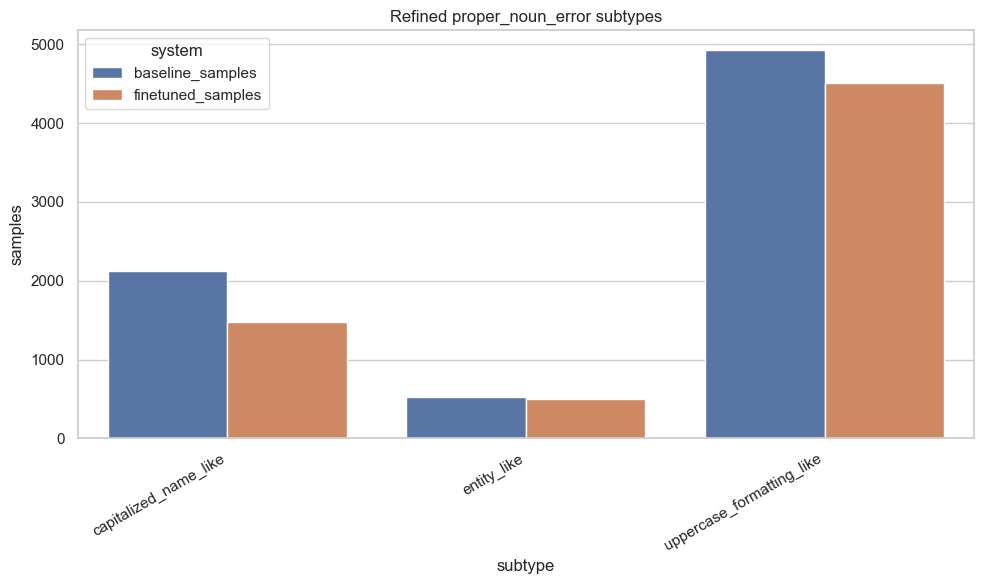

In [13]:
plot_df = proper_noun_subtype_distribution_df.melt(
    id_vars="subtype",
    value_vars=["baseline_samples", "finetuned_samples"],
    var_name="system",
    value_name="samples",
)

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="subtype", y="samples", hue="system")
plt.xticks(rotation=30, ha="right")
plt.title("Refined proper_noun_error subtypes")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "proper_noun_subtype_distribution.png", dpi=150)
plt.show()


## Cell 15 — Plot subtype failure rates


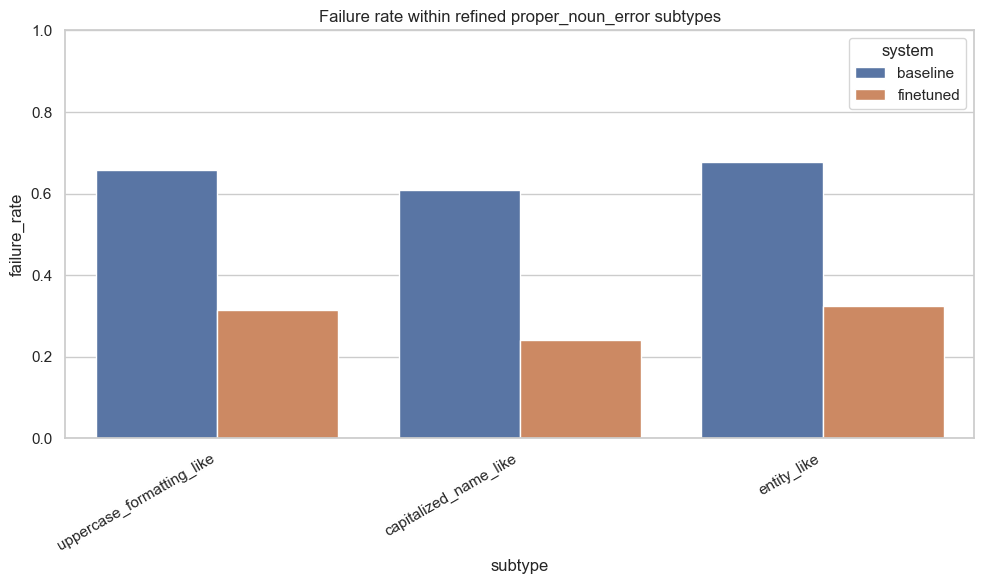

In [14]:
if not refined_proper_noun_impact_df.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=refined_proper_noun_impact_df, x="subtype", y="failure_rate", hue="system")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 1.0)
    plt.title("Failure rate within refined proper_noun_error subtypes")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "proper_noun_subtype_failure_rates.png", dpi=150)
    plt.show()
else:
    print("No refined proper_noun_error rows available.")


## Cell 16 — Decide whether the taxonomy is trustworthy enough to continue


In [15]:
validation_summary = {
    "baseline_proper_noun_fraction": float((refined_df["baseline_primary_error_type"] == "proper_noun_error").mean()),
    "finetuned_proper_noun_fraction": float((refined_df["finetuned_primary_error_type"] == "proper_noun_error").mean()),
    "n_baseline_subtypes": int(baseline_subtype_impact_df.shape[0]),
    "n_finetuned_subtypes": int(finetuned_subtype_impact_df.shape[0]),
    "taxonomy_needs_more_refinement": bool((refined_df["baseline_primary_error_type"] == "proper_noun_error").mean() > 0.7),
}

validation_summary


{'baseline_proper_noun_fraction': 0.8716620626151013,
 'finetuned_proper_noun_fraction': 0.7466620626151013,
 'n_baseline_subtypes': 3,
 'n_finetuned_subtypes': 3,
 'taxonomy_needs_more_refinement': True}

## Cell 17 — Save validation artifacts


In [16]:
baseline_validation_sample_df.to_csv(REPORTS_DIR / "taxonomy_validation_sample_baseline.csv", index=False)
finetuned_validation_sample_df.to_csv(REPORTS_DIR / "taxonomy_validation_sample_finetuned.csv", index=False)
proper_noun_subtype_distribution_df.to_csv(REPORTS_DIR / "proper_noun_subtype_distribution.csv", index=False)
refined_proper_noun_impact_df.to_csv(REPORTS_DIR / "proper_noun_subtype_impact.csv", index=False)

with open(REPORTS_DIR / "taxonomy_validation_summary_13.json", "w", encoding="utf-8") as f:
    json.dump(validation_summary, f, indent=2)

print("Saved taxonomy validation artifacts.")


Saved taxonomy validation artifacts.


## Cell 18 — Final interpretation

After this notebook, you should know whether the repaired taxonomy is merely functional or actually credible enough for publication-oriented analysis.

If `proper_noun_error` still dominates too broadly, then the next notebook should refine the taxonomy further before making strong claims.

If the subtype breakdown is meaningful and stable, then you are ready for:

- **14_high_impact_error_analysis**
- **15_is_wer_a_good_proxy**
- **16_predict_intent_change_from_asr_error**


In [17]:
print("=" * 72)
print("TAXONOMY VALIDATION AND REFINEMENT SUMMARY")
print("=" * 72)
for k, v in validation_summary.items():
    print(f"- {k}: {v}")
print()
print("Saved:")
print("- taxonomy_validation_sample_baseline.csv")
print("- taxonomy_validation_sample_finetuned.csv")
print("- proper_noun_subtype_distribution.csv")
print("- proper_noun_subtype_impact.csv")
print("- taxonomy_validation_summary_13.json")


TAXONOMY VALIDATION AND REFINEMENT SUMMARY
- baseline_proper_noun_fraction: 0.8716620626151013
- finetuned_proper_noun_fraction: 0.7466620626151013
- n_baseline_subtypes: 3
- n_finetuned_subtypes: 3
- taxonomy_needs_more_refinement: True

Saved:
- taxonomy_validation_sample_baseline.csv
- taxonomy_validation_sample_finetuned.csv
- proper_noun_subtype_distribution.csv
- proper_noun_subtype_impact.csv
- taxonomy_validation_summary_13.json
